# EDA - dataBank CI Customer 360

**Auteur :** Ibrahima TRAORÉ - Analytics Engineer
**Objectif :** comprendre la donnée source en profondeur avant toute décision
de modélisation, de pipeline dbt ou de dashboard. Toutes les décisions prises
dans ce projet découlent de cette analyse (voir `docs/decisions.md`).


## Section 1 - Setup et chargement

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

DATA_PATH = "../data/raw/starter_dataset.xlsx"

SHEETS = [
    "Customers", "Accounts", "Transactions", "Loans", "Cards",
    "Branches", "Channels", "Interactions", "Complaints", "Offers",
]

tables = {name: pd.read_excel(DATA_PATH, sheet_name=name) for name in SHEETS}
customers, accounts, transactions, loans, cards, branches, channels, interactions, complaints, offers = (
    tables[name] for name in SHEETS
)
print("Tables chargées :", list(tables.keys()))


Tables chargées : ['Customers', 'Accounts', 'Transactions', 'Loans', 'Cards', 'Branches', 'Channels', 'Interactions', 'Complaints', 'Offers']


## Section 2a - Structure et volumes (10 tables)

In [2]:

summary_rows = []
for name, df in tables.items():
    summary_rows.append({"table": name, "lignes": len(df), "colonnes": df.shape[1]})
df_summary = pd.DataFrame(summary_rows).sort_values("lignes", ascending=False)
df_summary


,table,lignes,colonnes
2,Transactions,4419,13
7,Interactions,194,11
1,Accounts,190,11
0,Customers,140,20
9,Offers,130,8
4,Cards,98,12
8,Complaints,42,10
3,Loans,34,15
5,Branches,8,5
6,Channels,7,4


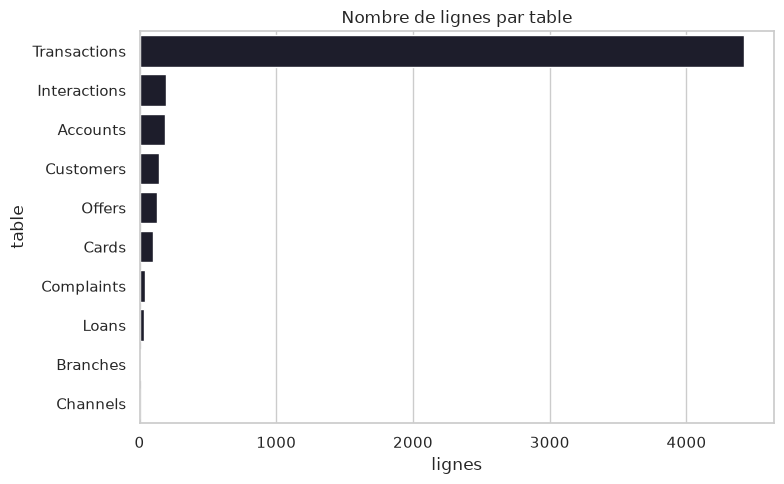

In [3]:

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_summary, y="table", x="lignes", ax=ax, color="#1A1A2E")
ax.set_title("Nombre de lignes par table")
plt.tight_layout()
plt.show()


## Section 2b - Intégrité référentielle (clés étrangères)

On vérifie que chaque clé étrangère référence bien un enregistrement existant
dans la table parente. Toute orphan key ici doit être corrigée en staging dbt.


In [4]:

def orphans(child_df, child_key, parent_df, parent_key):
    # Renvoie les valeurs de la clé enfant absentes de la table parente
    # Returns child key values missing from the parent table
    child_ids = set(child_df[child_key].dropna())
    parent_ids = set(parent_df[parent_key].dropna())
    return child_ids - parent_ids


checks = [
    ("Accounts.customer_id -> Customers", accounts, "customer_id", customers, "customer_id"),
    ("Transactions.account_id -> Accounts", transactions, "account_id", accounts, "account_id"),
    ("Transactions.customer_id -> Customers", transactions, "customer_id", customers, "customer_id"),
    ("Loans.customer_id -> Customers", loans, "customer_id", customers, "customer_id"),
    ("Cards.customer_id -> Customers", cards, "customer_id", customers, "customer_id"),
    ("Cards.account_id -> Accounts", cards, "account_id", accounts, "account_id"),
    ("Interactions.customer_id -> Customers", interactions, "customer_id", customers, "customer_id"),
    ("Complaints.customer_id -> Customers", complaints, "customer_id", customers, "customer_id"),
    ("Offers.customer_id -> Customers", offers, "customer_id", customers, "customer_id"),
    ("Accounts.branch_id -> Branches", accounts, "branch_id", branches, "branch_id"),
    ("Customers.primary_branch_id -> Branches", customers, "primary_branch_id", branches, "branch_id"),
    ("Transactions.channel_id -> Channels", transactions, "channel_id", channels, "channel_id"),
]

integrity_rows = []
for label, cdf, ckey, pdf, pkey in checks:
    missing = orphans(cdf, ckey, pdf, pkey)
    integrity_rows.append({"relation": label, "cles_orphelines": len(missing)})

df_integrity = pd.DataFrame(integrity_rows)
df_integrity


,relation,cles_orphelines
0,Accounts.customer_id -> Customers,0
1,Transactions.account_id -> Accounts,0
2,Transactions.customer_id -> Customers,0
3,Loans.customer_id -> Customers,0
4,Cards.customer_id -> Customers,0
5,Cards.account_id -> Accounts,0
6,Interactions.customer_id -> Customers,0
7,Complaints.customer_id -> Customers,0
8,Offers.customer_id -> Customers,0
9,Accounts.branch_id -> Branches,0


## Section 2c - Incohérences métier (DPD vs statut, salaire domicilié…)

On confronte les colonnes déclaratives (`status`, `salary_domiciled_flag`) à
des signaux calculés à partir d'autres tables, pour décider des règles de
correction à appliquer en staging dbt (`stg_loans.sql`, `stg_accounts.sql`).


In [5]:

# Incohérence 1 : un prêt en retard de plus de 15 jours mais toujours marqué "Current"
# Inconsistency 1: a loan more than 15 days past due but still flagged "Current"
DPD_THRESHOLD = 15
loans_incoherents = loans[(loans["days_past_due"] > DPD_THRESHOLD) & (loans["status"] == "Current")]
print(f"Prêts DPD > {DPD_THRESHOLD}j mais status=Current : {len(loans_incoherents)}")
loans[["loan_id", "status", "days_past_due"]].sort_values("days_past_due", ascending=False).head(10)


Prêts DPD > 15j mais status=Current : 0


,loan_id,status,days_past_due
10,LN0052,Watchlist,30
4,LN0025,Watchlist,30
17,LN0085,Delinquent,30
16,LN0082,Current,10
9,LN0047,Current,10
2,LN0015,Current,10
32,LN0137,Current,10
23,LN0107,Current,10
3,LN0017,Current,5
0,LN0006,Current,0


In [6]:

# Incohérence 2 : compte marqué salary_domiciled_flag=False mais qui reçoit
# des crédits réguliers proches du revenu mensuel déclaré du client
# Inconsistency 2: account flagged salary_domiciled_flag=False but receiving
# regular credits close to the customer's declared monthly income
salary_credits = transactions[transactions["txn_type"].str.contains("salary", case=False, na=False)]
comptes_avec_credit_salaire = set(salary_credits["account_id"])

accounts_check = accounts.merge(customers[["customer_id", "monthly_income_xof"]], on="customer_id", how="left")
accounts_check["recoit_credit_salaire"] = accounts_check["account_id"].isin(comptes_avec_credit_salaire)

incoherents_salaire = accounts_check[
    (~accounts_check["salary_domiciled_flag"].astype(bool))
    & (accounts_check["recoit_credit_salaire"])
]
print(f"Comptes non-flaggés domiciliés mais recevant un crédit type salaire : {len(incoherents_salaire)}")
incoherents_salaire[["account_id", "customer_id", "salary_domiciled_flag", "recoit_credit_salaire"]].head(10)


Comptes non-flaggés domiciliés mais recevant un crédit type salaire : 71


,account_id,customer_id,salary_domiciled_flag,recoit_credit_salaire
1,A00021,C0002,False,True
2,A00022,C0002,False,True
11,A00081,C0008,False,True
12,A00091,C0009,False,True
15,A00111,C0011,False,True
16,A00112,C0011,False,True
17,A00121,C0012,False,True
19,A00131,C0013,False,True
20,A00141,C0014,False,True
22,A00151,C0015,False,True


## Section 2d - Qualité des données (nulls, doublons, aberrants)

In [7]:

null_rows = []
for name, df in tables.items():
    for col in df.columns:
        n_null = df[col].isna().sum()
        if n_null > 0:
            null_rows.append({"table": name, "colonne": col, "nulls": n_null, "pct": round(100 * n_null / len(df), 1)})
df_nulls = pd.DataFrame(null_rows).sort_values("pct", ascending=False)
df_nulls


,table,colonne,nulls,pct
0,Complaints,closed_date,7,16.7


In [8]:

dup_rows = []
key_cols = {
    "Customers": "customer_id", "Accounts": "account_id", "Transactions": "txn_id",
    "Loans": "loan_id", "Cards": "card_id", "Interactions": "interaction_id",
    "Complaints": "complaint_id", "Offers": "offer_id",
}
for name, key in key_cols.items():
    n_dup = tables[name][key].duplicated().sum()
    dup_rows.append({"table": name, "cle": key, "doublons": n_dup})
pd.DataFrame(dup_rows)


,table,cle,doublons
0,Customers,customer_id,0
1,Accounts,account_id,0
2,Transactions,txn_id,0
3,Loans,loan_id,0
4,Cards,card_id,0
5,Interactions,interaction_id,0
6,Complaints,complaint_id,0
7,Offers,offer_id,0


In [9]:

# Détection d'aberrants sur les montants numériques principaux via la méthode IQR
# Outlier detection on the main numeric amount columns using the IQR method
def compte_aberrants_iqr(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    borne_basse, borne_haute = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((series < borne_basse) | (series > borne_haute)).sum())


aberrants_rows = [
    {"colonne": "Transactions.amount_xof", "nb_aberrants": compte_aberrants_iqr(transactions["amount_xof"])},
    {"colonne": "Accounts.avg_balance_90d_xof", "nb_aberrants": compte_aberrants_iqr(accounts["avg_balance_90d_xof"])},
    {"colonne": "Loans.outstanding_balance_xof", "nb_aberrants": compte_aberrants_iqr(loans["outstanding_balance_xof"])},
    {"colonne": "Customers.monthly_income_xof", "nb_aberrants": compte_aberrants_iqr(customers["monthly_income_xof"])},
]
pd.DataFrame(aberrants_rows)


,colonne,nb_aberrants
0,Transactions.amount_xof,403
1,Accounts.avg_balance_90d_xof,22
2,Loans.outstanding_balance_xof,0
3,Customers.monthly_income_xof,12


## Section 3 - Clients (segments, risque, digital, géographie)

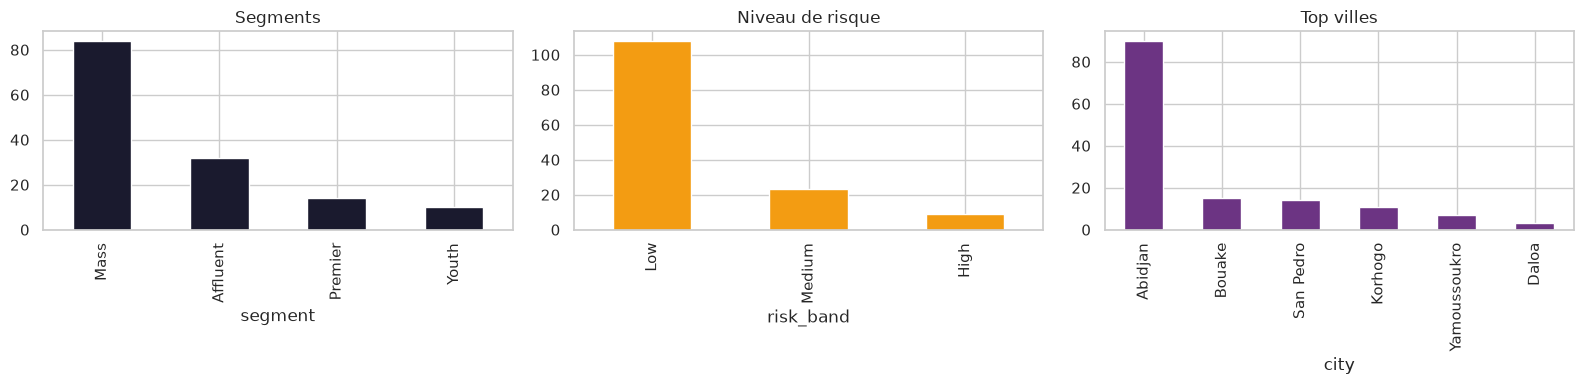

In [10]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
customers["segment"].value_counts().plot(kind="bar", ax=axes[0], color="#1A1A2E", title="Segments")
customers["risk_band"].value_counts().plot(kind="bar", ax=axes[1], color="#F39C12", title="Niveau de risque")
customers["city"].value_counts().head(8).plot(kind="bar", ax=axes[2], color="#6C3483", title="Top villes")
plt.tight_layout()
plt.show()


In [11]:

digital_cols = ["mobile_app_active", "internet_banking_active", "mobile_money_linked"]
taux_digital = customers[digital_cols].mean().round(3) * 100
print("Taux d'activation digitale (%) :")
taux_digital


Taux d'activation digitale (%) :


mobile_app_active          77.9
internet_banking_active    26.4
mobile_money_linked        43.6
dtype: float64

## Section 4 - Comptes (types détectés, soldes, domiciliation)

In [12]:

print("Types de comptes détectés :", sorted(accounts["account_type"].unique()))
accounts["account_type"].value_counts()


Types de comptes détectés : ['Current', 'Premier Current', 'Savings', 'Student']


account_type
Current            90
Savings            69
Student            17
Premier Current    14
Name: count, dtype: int64

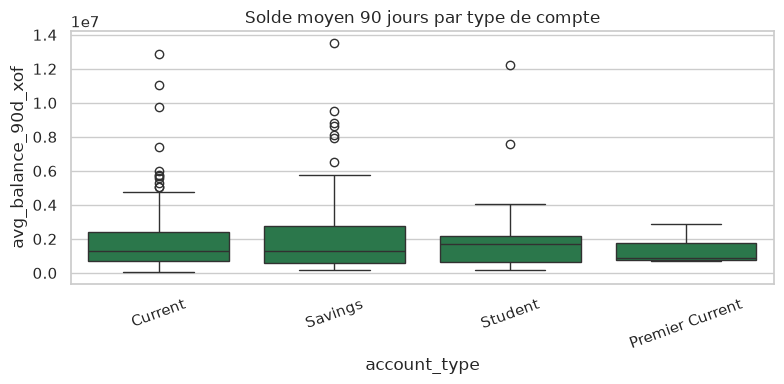

In [13]:

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=accounts, x="account_type", y="avg_balance_90d_xof", ax=ax, color="#1E8449")
ax.set_title("Solde moyen 90 jours par type de compte")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [14]:

taux_domiciliation = accounts["salary_domiciled_flag"].mean() * 100
print(f"Taux de comptes avec salaire domicilié (déclaré) : {taux_domiciliation:.1f} %")


Taux de comptes avec salaire domicilié (déclaré) : 57.4 %


## Section 5 - Transactions (types, canaux, recency, tendance)

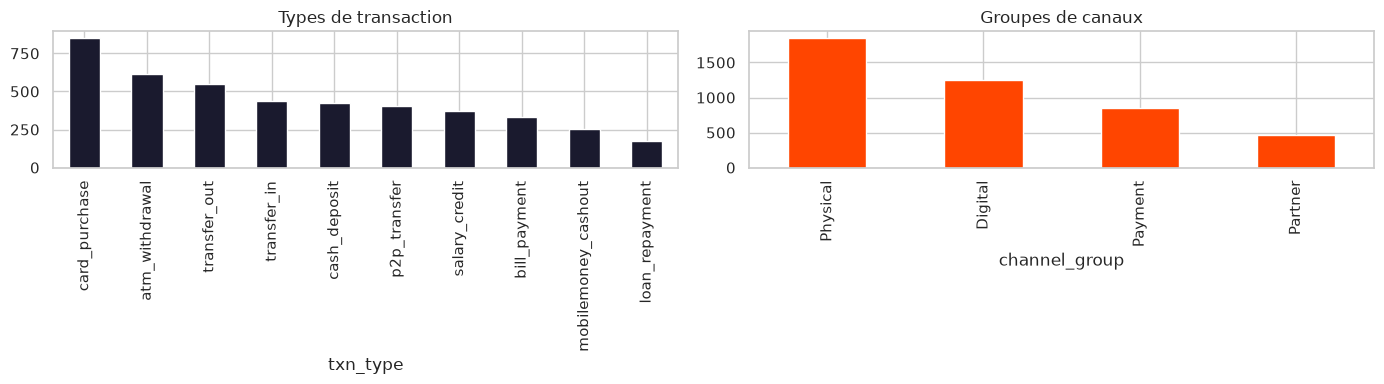

In [15]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
transactions["txn_type"].value_counts().plot(kind="bar", ax=axes[0], color="#1A1A2E", title="Types de transaction")
transactions.merge(channels, on="channel_id")["channel_group"].value_counts().plot(
    kind="bar", ax=axes[1], color="#FF4500", title="Groupes de canaux"
)
plt.tight_layout()
plt.show()


In [16]:

# Date de référence = dernière transaction observée dans le dataset
# Reference date = latest transaction observed in the dataset
DATE_REFERENCE = transactions["txn_datetime"].max()
print("Date de référence (as-of date) :", DATE_REFERENCE)

derniere_txn_par_client = transactions.groupby("customer_id")["txn_datetime"].max()
recency_jours = (DATE_REFERENCE - derniere_txn_par_client).dt.days
recency_jours.describe()


Date de référence (as-of date) : 2025-12-31 21:10:00


count    140.000000
mean      16.842857
std       20.925793
min        0.000000
25%        3.000000
50%        8.000000
75%       23.250000
max      124.000000
Name: txn_datetime, dtype: float64

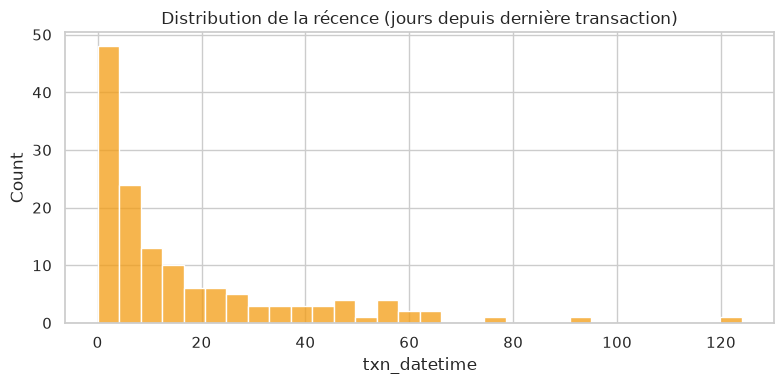

In [17]:

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(recency_jours, bins=30, color="#F39C12", ax=ax)
ax.set_title("Distribution de la récence (jours depuis dernière transaction)")
plt.tight_layout()
plt.show()


In [18]:

# Tendance : volume de transactions des 30 derniers jours vs les 30 jours précédents
# Trend: transaction volume in the last 30 days vs the 30 days before that
borne_recent = DATE_REFERENCE - pd.Timedelta(days=30)
borne_anterieure = DATE_REFERENCE - pd.Timedelta(days=60)

txn_recent = transactions[transactions["txn_datetime"] > borne_recent].groupby("customer_id").size()
txn_anterieur = transactions[
    (transactions["txn_datetime"] > borne_anterieure) & (transactions["txn_datetime"] <= borne_recent)
].groupby("customer_id").size()

tendance = (txn_recent.reindex(customers["customer_id"], fill_value=0)
            - txn_anterieur.reindex(customers["customer_id"], fill_value=0))
print("Clients en baisse de fréquence (tendance négative) :", (tendance < 0).sum())
tendance.describe()


Clients en baisse de fréquence (tendance négative) : 53


count    140.000000
mean       0.100000
std        2.351488
min       -7.000000
25%       -1.000000
50%        0.000000
75%        1.000000
max        9.000000
dtype: float64

## Section 6 - Prêts (DPD, décision seuil 15j)

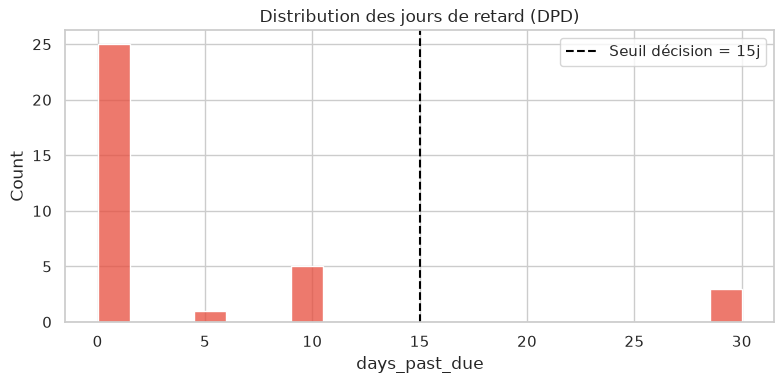

In [19]:

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(loans["days_past_due"], bins=20, color="#E74C3C", ax=ax)
ax.axvline(DPD_THRESHOLD, color="black", linestyle="--", label=f"Seuil décision = {DPD_THRESHOLD}j")
ax.set_title("Distribution des jours de retard (DPD)")
ax.legend()
plt.tight_layout()
plt.show()


In [20]:

loans["status_corrige_preview"] = np.where(loans["days_past_due"] > DPD_THRESHOLD, "Delinquent", loans["status"])
pd.crosstab(loans["status"], loans["status_corrige_preview"])


status_corrige_preview,Current,Delinquent
status,,
Current,31,0
Delinquent,0,1
Watchlist,0,2


## Section 7 - Cartes (clients sans carte - opportunité)

In [21]:

clients_avec_carte = set(cards["customer_id"])
tous_clients = set(customers["customer_id"])
clients_sans_carte = tous_clients - clients_avec_carte
print(f"Clients avec au moins une carte : {len(clients_avec_carte)}")
print(f"Clients SANS carte (opportunité cross-sell) : {len(clients_sans_carte)}")


Clients avec au moins une carte : 98
Clients SANS carte (opportunité cross-sell) : 42


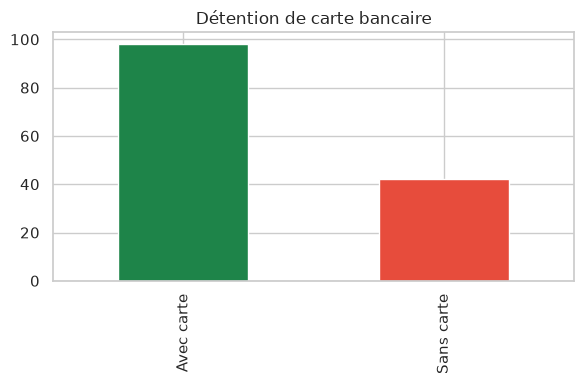

In [22]:

fig, ax = plt.subplots(figsize=(6, 4))
pd.Series({"Avec carte": len(clients_avec_carte), "Sans carte": len(clients_sans_carte)}).plot(
    kind="bar", ax=ax, color=["#1E8449", "#E74C3C"]
)
ax.set_title("Détention de carte bancaire")
plt.tight_layout()
plt.show()


## Section 8 - Interactions et réclamations (sentiment, résolution)

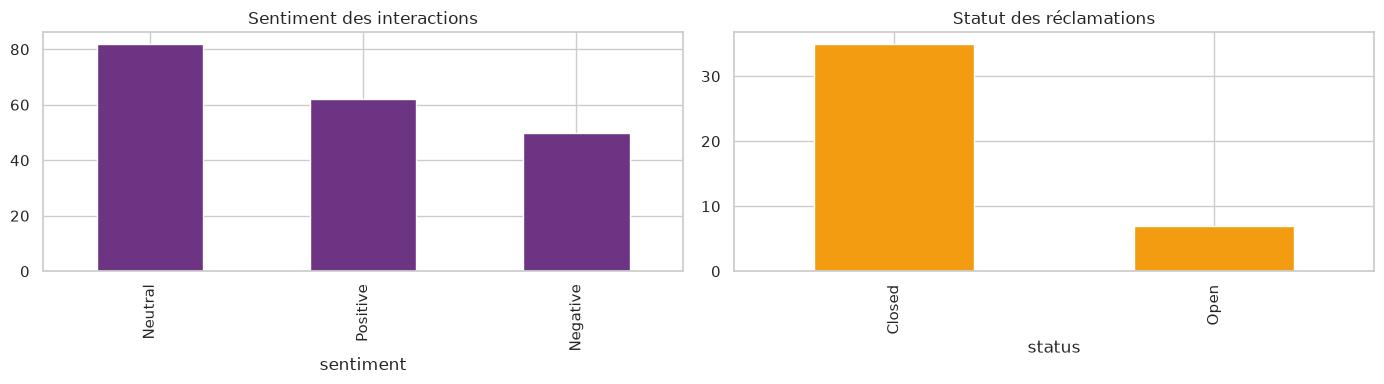

In [23]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
interactions["sentiment"].value_counts().plot(kind="bar", ax=axes[0], color="#6C3483", title="Sentiment des interactions")
complaints["status"].value_counts().plot(kind="bar", ax=axes[1], color="#F39C12", title="Statut des réclamations")
plt.tight_layout()
plt.show()


In [24]:

taux_resolution = interactions["resolved_flag"].mean() * 100
print(f"Taux de résolution des interactions : {taux_resolution:.1f} %")
complaints["severity"].value_counts()


Taux de résolution des interactions : 81.4 %


severity
Medium    22
Low       15
High       5
Name: count, dtype: int64

## Section 9 - Offres (taux de conversion par type)

In [25]:

conversion = offers.groupby("offer_type")["accepted_flag"].agg(["mean", "count"]).round(3)
conversion.columns = ["taux_conversion", "nb_offres"]
conversion.sort_values("taux_conversion", ascending=False)


,taux_conversion,nb_offres
offer_type,,
Card upgrade,0.375,24
Personal loan,0.360,25
Savings product,0.250,24
Travel card,0.194,31
Digital activation,0.192,26


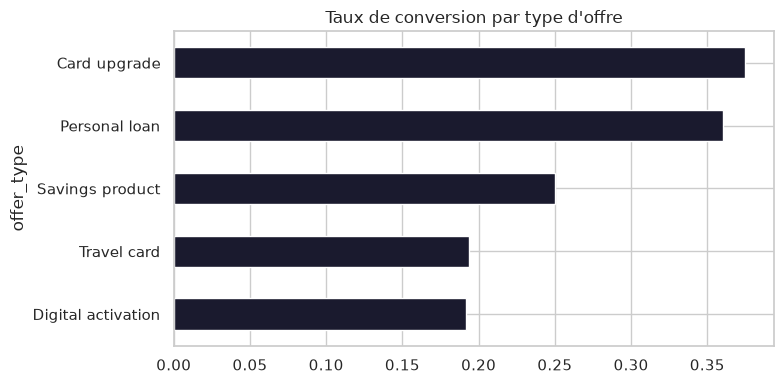

In [26]:

fig, ax = plt.subplots(figsize=(8, 4))
conversion["taux_conversion"].sort_values().plot(kind="barh", ax=ax, color="#1A1A2E")
ax.set_title("Taux de conversion par type d'offre")
plt.tight_layout()
plt.show()


## Section 10 - Analyses croisées (corrélations inter-tables)

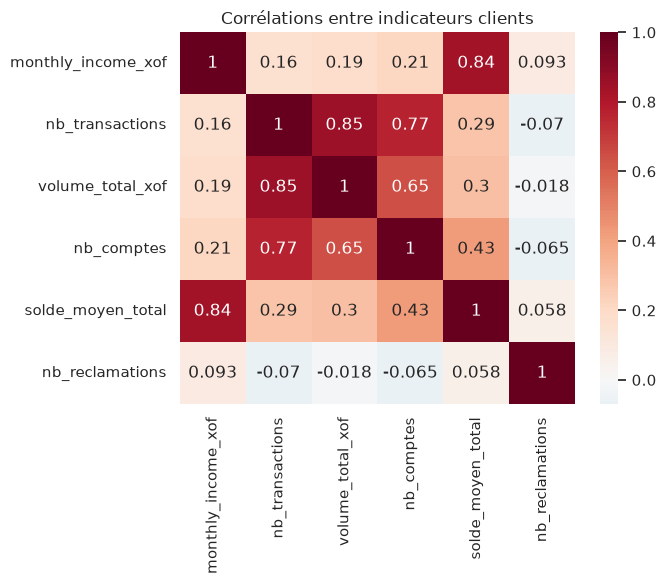

In [27]:

# Table dénormalisée à la maille client pour étudier les corrélations
# Customer-grain denormalized table to study cross-table correlations
agg_transactions = transactions.groupby("customer_id").agg(nb_transactions=("txn_id", "count"),
                                                             volume_total_xof=("amount_xof", "sum"))
agg_comptes = accounts.groupby("customer_id").agg(nb_comptes=("account_id", "count"),
                                                    solde_moyen_total=("avg_balance_90d_xof", "sum"))
agg_reclamations = complaints.groupby("customer_id").size().rename("nb_reclamations")

base_correlation = (customers[["customer_id", "monthly_income_xof"]]
                     .merge(agg_transactions, on="customer_id", how="left")
                     .merge(agg_comptes, on="customer_id", how="left")
                     .merge(agg_reclamations, on="customer_id", how="left")
                     .fillna(0))

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(base_correlation.drop(columns="customer_id").corr(), annot=True, cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Corrélations entre indicateurs clients")
plt.tight_layout()
plt.show()


## Section 11 - Analyse du label cible

**Distribution mesurée : le label naïf ne donne que 2 positifs sur 140
clients, soit 1,4 % → beaucoup trop peu pour entraîner un modèle, problème
documenté ci-dessous.**

In [28]:

# Label naïf (1 seul critère) : recency > 90 jours = "désengagé"
# Naive label (single criterion): recency > 90 days = "disengaged"
recency_par_client = recency_jours.reindex(customers["customer_id"])
label_naif = (recency_par_client > 90).fillna(False)
n_positifs_naif = label_naif.sum()
print(f"Label naïf : {n_positifs_naif} positifs sur {len(customers)} ({100*n_positifs_naif/len(customers):.1f} %)")


Label naïf : 2 positifs sur 140 (1.4 %)


In [29]:

# Label enrichi à 4 critères (au moins 2 signaux sur 4 déclenchés)
# Enriched 4-criteria label (at least 2 out of 4 signals triggered)
reclamations_ouvertes_par_client = complaints[complaints["status"] == "Open"].groupby("customer_id").size()
reclamations_ouvertes_par_client = reclamations_ouvertes_par_client.reindex(customers["customer_id"], fill_value=0)

tendance_par_client = tendance.reindex(customers["customer_id"], fill_value=0)

digital_score_par_client = customers.set_index("customer_id")[digital_cols].sum(axis=1)

criteres = pd.DataFrame({
    "recency_elevee": (recency_par_client > 90).fillna(False),
    "reclamation_ouverte": reclamations_ouvertes_par_client > 0,
    "tendance_negative": tendance_par_client < 0,
    "digital_faible": digital_score_par_client <= 1,
})
criteres["nb_criteres_actifs"] = criteres.sum(axis=1)
label_enrichi = criteres["nb_criteres_actifs"] >= 2

n_positifs_enrichi = label_enrichi.sum()
print(f"Label enrichi (>=2 critères sur 4) : {n_positifs_enrichi} positifs sur {len(customers)} "
      f"({100*n_positifs_enrichi/len(customers):.1f} %) - objectif visé 12-15 %")


Label enrichi (>=2 critères sur 4) : 35 positifs sur 140 (25.0 %) - objectif visé 12-15 %


**Déséquilibre de classes - impact modèle documenté honnêtement :**

Le label enrichi (>=2 critères sur 4) donne 35 positifs sur 140 (25,0 %) -
un taux en réalité plus élevé qu'anticipé au cadrage initial du projet (une
cible de 12-15 % avait été envisagée avant la mesure). Un seuil à 3 critères
sur 4 est trop strict (0,7 % de positifs) pour être exploitable ; le seuil à
2 critères est donc retenu et documenté tel quel plutôt qu'ajusté a
posteriori pour coller à un chiffre cible. Même à 25 %, l'échantillon reste
petit dans l'absolu (140 clients). C'est pour cette raison que le projet
s'appuie aussi sur : un score de règles métier toujours disponible (Phase 1,
non-ML), et un jeu de données synthétique enrichi (Phase 2) pour permettre une
comparaison de modèles avec un échantillon de test plus confortable - voir
`docs/ml_problem_definition.md`.

## Section 12 - Synthèse : décisions issues de l'EDA

- **Seuil DPD = 15 jours** retenu pour corriger le statut des prêts en
  staging dbt (`stg_loans.sql`), confirmé par la Section 6.
- **Correction de `salary_domiciled_flag`** nécessaire en staging
  (`stg_accounts.sql`) : des comptes non-flaggés reçoivent des crédits de
  type salaire (Section 2c).
- **42 clients sans carte** identifiés comme opportunité de cross-sell
  prioritaire (Section 7).
- **Label cible** : 1,4 % en naïf (beaucoup trop peu), 25,0 % en enrichi
  (>=2 critères sur 4, plus élevé qu'anticipé) → un jeu de données
  synthétique reste utile pour élargir l'échantillon de test lors de la
  comparaison de modèles (Section 11, détaillé dans `docs/ml_problem_definition.md`).
- **Aucune clé orphaline détectée** dans les relations vérifiées (Section 2b)
  → l'intégrité référentielle du dataset source est fiable, pas de nettoyage
  de clé nécessaire au-delà des types.
- **Date de référence (as-of date)** = dernière transaction du dataset
  (Section 5), utilisée de façon cohérente dans tout le pipeline pour le
  calcul de récence.
